# 01 — Black-Scholes-Merton: European Option Pricing

This notebook is the foundation of the project. It demonstrates:

1. Pricing a European call and put under BSM
2. Verifying put-call parity (model-free, no-arbitrage check)
3. Computing Greeks for sensivity check
4. Visualising price and Greeks across a range of strikes
5. Recovering implied volatility from a market price

See `README.md` — Theory — BSM Model Assumptions for the full mathematical derivation and the seven assumptions underlying this model.

In [3]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.engines.analytical import BSMModel

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

Matplotlib is building the font cache; this may take a moment.


## Pricing a Single Option

We start with a standard at-the-money example: a 1-year option on a \$100 stock, 20% volatility, 5% risk-free rate, no dividends.


In [4]:
S, K, T, r, sigma, q = 100.0, 100.0, 1.0, 0.05, 0.20, 0.0

bsm = BSMModel(S=S, K=K, T=T, r=r, sigma=sigma, q=q)

call_price = bsm.price("call")
put_price  = bsm.price("put")

print(f"Call price : {call_price:.4f}")
print(f"Put price  : {put_price:.4f}")

Call price : 10.4506
Put price  : 5.5735


## Put-Call Parity Check

Put-call parity is a **model-free** no-arbitrage relationship:

$$
C - P = S * e^{-qT} - K * e^{-rT}
$$


It must hold regardless of which model produced C and P. We verify it holds exactly for our BSM prices above.

In [5]:
lhs = call_price - put_price
rhs = S * np.exp(-q * T) - K * np.exp(-r * T)

print(f"C - P = {lhs:.6f}")
print(f"S*e^-qT - K*e^-rT = {rhs:.6f}")
print(f"Difference = {abs(lhs - rhs):.2e}")

assert bsm.put_call_parity_check()
print("\nParity holds.")

C - P = 4.877058
S*e^-qT - K*e^-rT = 4.877058
Difference = 0.00e+00

Parity holds.


## Greeks

Greeks measure the sensitivity of the option price to each input. `BSMModel.all_greeks()` returns all eight (five first-order, three second-order/cross Greeks) in one call.

In [6]:
greeks_call = bsm.all_greeks("call")
greeks_put  = bsm.all_greeks("put")

print(f"{'Greek':<8} {'Call':>10} {'Put':>10}")
print("-" * 30)
for name in ("delta", "gamma", "vega", "theta", "rho", "vanna", "volga", "charm"):
    print(f"{name:<8} {float(greeks_call[name]):>10.4f} {float(greeks_put[name]):>10.4f}")

Greek          Call        Put
------------------------------
delta        0.6368    -0.3632
gamma        0.0188     0.0188
vega        37.5240    37.5240
theta       -0.0176    -0.0045
rho         53.2325   -41.8905
vanna       -0.2814    -0.2814
volga        9.8501     9.8501
charm       -0.0002    -0.0002


**Sanity checks**

- Call delta $\in$ (0,1), put delta $\in$ (−1,0)
- Gamma and vega are identical for calls and puts
- Theta is negative for both (time decay)
- Call rho > 0 (higher rates raise call value), put rho < 0

## Price and Greeks Across Strikes

`BSMModel` accepts array inputs and broadcasts automatically. We price an entire range of strikes in one vectorised call, then plot
price and Greeks as the option moves from OTM through ATM to ITM.

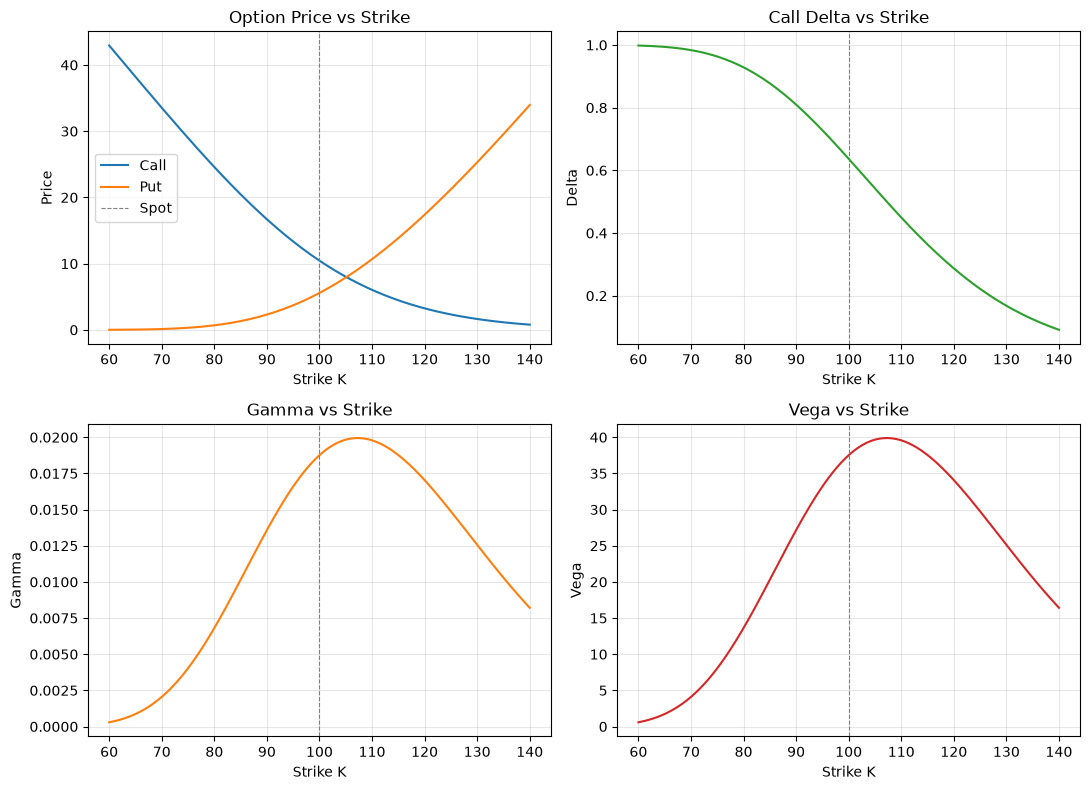

In [7]:
strikes = np.linspace(60, 140, 200)

bsm_strip = BSMModel(S=S, K=strikes, T=T, r=r, sigma=sigma, q=q)

call_prices = bsm_strip.price("call")
put_prices  = bsm_strip.price("put")
delta_call  = bsm_strip.delta("call")
gamma = bsm_strip.gamma()
vega = bsm_strip.vega()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(strikes, call_prices, label="Call")
axes[0, 0].plot(strikes, put_prices, label="Put")
axes[0, 0].axvline(S, color="gray", linestyle="--", lw=0.8, label="Spot")
axes[0, 0].set_title("Option Price vs Strike")
axes[0, 0].set_xlabel("Strike K")
axes[0, 0].set_ylabel("Price")
axes[0, 0].legend()

axes[0, 1].plot(strikes, delta_call, color="tab:green")
axes[0, 1].axvline(S, color="gray", linestyle="--", lw=0.8)
axes[0, 1].set_title("Call Delta vs Strike")
axes[0, 1].set_xlabel("Strike K")
axes[0, 1].set_ylabel("Delta")

axes[1, 0].plot(strikes, gamma, color="tab:orange")
axes[1, 0].axvline(S, color="gray", linestyle="--", lw=0.8)
axes[1, 0].set_title("Gamma vs Strike")
axes[1, 0].set_xlabel("Strike K")
axes[1, 0].set_ylabel("Gamma")

axes[1, 1].plot(strikes, vega, color="tab:red")
axes[1, 1].axvline(S, color="gray", linestyle="--", lw=0.8)
axes[1, 1].set_title("Vega vs Strike")
axes[1, 1].set_xlabel("Strike K")
axes[1, 1].set_ylabel("Vega")

plt.tight_layout()
plt.show()

**Observations** 

- Call price falls monotonically as K rises (more OTM); put price rises monotonically as K rises
- Delta transitions smoothly from 1 (deep ITM call) to 0 (deep OTM)
- Gamma and vega both peak at-the-money (K = S). This is where the option's value is most sensitive to small moves in spot or volatility because the outcome is most uncertain right at the strike

## Implied Volatility

Implied volatility answers question of "given the market price, what $\sigma$ makes BSM agree with the market?"

`BSMModel.implied_vol()` uses Newton-Raphson with a Brent's method fallback (robust) for cases where vega is too small for Newton to converge.


In [8]:
# Suppose the market quotes this call at 12.00 (above our BSM price of 10.45, implying the market is pricing in higher volatility than 20%)
market_price = 12.00

iv = BSMModel.implied_vol(
    market_price=market_price,
    S=S, K=K, T=T, r=r, q=q,
    option_type="call",
)

print(f"Market price : {market_price:.4f}")
print(f"Implied vol : {iv:.4%}")

# Feeding the implied vol back into BSM should reproduce the market price exactly
recovered_price = BSMModel(S, K, T, r, iv, q).price("call")
print(f"Recovered price   : {recovered_price:.4f}")
print(f"Round-trip error  : {abs(recovered_price - market_price):.2e}")

Market price : 12.0000
Implied vol : 24.1117%
Recovered price   : 12.0000
Round-trip error  : 7.11e-15


## Summary

This notebook established the project's baseline:

| Check | Result |
|---|---|
| ATM call price | 10.4506 (matches reference) |
| Put-call parity | Holds |
| Greeks signs | All as expected (delta, gamma, vega, theta, rho) |
| Vanna finite-diff check | Matches analytical result |
| Implied volatility round-trip | Error 7.11e-15 (machine precision) |

Every following notebooks in this project benchmarks against the BSM prices and Greeks computed here. `02_monte_carlo.ipynb` validates Monte Carlo convergence to these same values, `03_american_options.ipynb` compares the early exercise premium against this European baseline, and so on.